# Make figures for Intro to Snow Hydro presentation

In [43]:
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from glob import glob
import contextily as ctx
import numpy as np
import seaborn as sns
import pandas as pd

OUT_DIR = "/Users/rdcrlrka/Research/SIRO/SIRO_Workshop_2026_figures"

plt.rcParams.update({'font.sans-serif': 'Arial', 'font.size': 12})

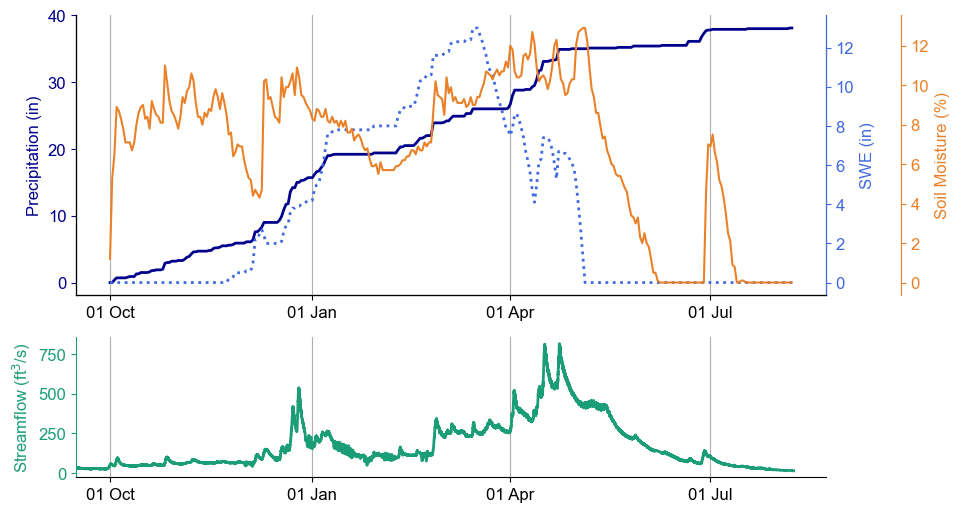

Figure saved to: /Users/rdcrlrka/Research/SIRO/SIRO_Workshop_2026_figures/SNOTEL_streamflow_example_MoresCreek_2025.png


In [44]:
import matplotlib.dates as mdates

# Set up figure
fig, ax = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [2,1]})
fig.subplots_adjust(right=0.75)

# --- SNOTEL ---
snotel_file = "/Users/rdcrlrka/Research/SkySat-Stereo/study-sites/MCS/snotel/637_ALL_WATERYEAR=2026.csv"

df = pd.read_csv(snotel_file, skiprows=6)
df = df.rename(columns={
    "WTEQ.I-1 (in) ": "SWE1",
    "WTEQ.I-2 (in) ": "SWE2",
    "PREC.I-1 (in) ": "Precip",
    "TAVG.D-1 (degC) ": "Temp_Mean",
    "SNWD.I-1 (in) ": "SnowDepth",
    "SMS.I-1:-2 (pct)  (silt)": "SoilMoisture2",
    "SMS.I-1:-8 (pct)  (silt)": "SoilMoisture8", 
    "SMS.I-1:-20 (pct)  (silt)": "SoilMoisture20"
})
df['Date'] = pd.to_datetime(df['Date'])

c_precip = 'darkblue'
c_swe = 'royalblue'
c_sm8 = '#ea8128'
sf_color = '#1b9e77'
lw = 2

# Precipitation (Left)
ax[0].plot(df['Date'], df['Precip'], '-', color=c_precip, label='Precipitation', linewidth=lw)
ax[0].set_ylabel('Precipitation (in)', color=c_precip)
ax[0].tick_params(axis='y', colors=c_precip)
ax[0].spines['left'].set_color(c_precip)

# SWE (Right 1)
ax1 = ax[0].twinx()
ax1.plot(df['Date'], df['SWE1'], ':', color=c_swe, label='SWE', linewidth=lw)
ax1.set_ylabel('SWE (in)', color=c_swe)
ax1.tick_params(axis='y', colors=c_swe)
ax1.spines['right'].set_color(c_swe)

# Soil Moisture (Right 2 - Offset)
ax2 = ax[0].twinx()
ax2.spines['right'].set_position(('axes', 1.1))
ax2.set_frame_on(True)
ax2.patch.set_visible(False)

ax2.plot(df['Date'], df['SoilMoisture8'], '-', color=c_sm8, label='SM 8"')
ax2.set_ylabel('Soil Moisture (%)', color=c_sm8)
ax2.tick_params(axis='y', colors=c_sm8)
ax2.spines['right'].set_color(c_sm8)


# --- Stream gauge ---
usgs_file = "/Users/rdcrlrka/Research/SkySat-Stereo/study-sites/MCS/snotel/MoresCreek_USGS_streamgauge_primary-time-series.csv"
usgs_df = pd.read_csv(usgs_file)
usgs_df['time'] = pd.to_datetime(usgs_df['time'])

ax[1].plot(usgs_df['time'], usgs_df['value'], '-', color=sf_color, linewidth=lw)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_ylabel('Streamflow (ft$^3$/s)', color=sf_color)
ax[1].tick_params(axis='y', colors=sf_color)
ax[1].spines['left'].set_color(sf_color)


# Remove some spines
for axis in [ax[0], ax[1], ax1, ax2]:
    axis.spines[['top']].set_visible(False)
    axis.grid(axis='x')
ax[1].spines['right'].set_visible(False)

# Set ticks to the 1st of Oct, Jan, Apr, Jul
months = mdates.MonthLocator(bymonth=[10, 1, 4, 7], bymonthday=1)
for axis in ax:
    axis.xaxis.set_major_locator(months)
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    axis.tick_params(axis='x', rotation=0)

plt.show()

fig_file = os.path.join(OUT_DIR, "SNOTEL_streamflow_example_MoresCreek_2025.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)


/Users/rdcrlrka/.local/share/mamba/envs/siro/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column beginDate, 1963-02-01T00:00:00.0Z, successfully parsed
  return ogr_read(


ConnectionError: HTTPSConnectionPool(host='server.arcgisonline.com', port=443): Max retries exceeded with url: /ArcGIS/rest/services/World_Shaded_Relief/MapServer/tile/5/7/1 (Caused by NameResolutionError("HTTPSConnection(host='server.arcgisonline.com', port=443): Failed to resolve 'server.arcgisonline.com' ([Errno 8] nodename nor servname provided, or not known)"))

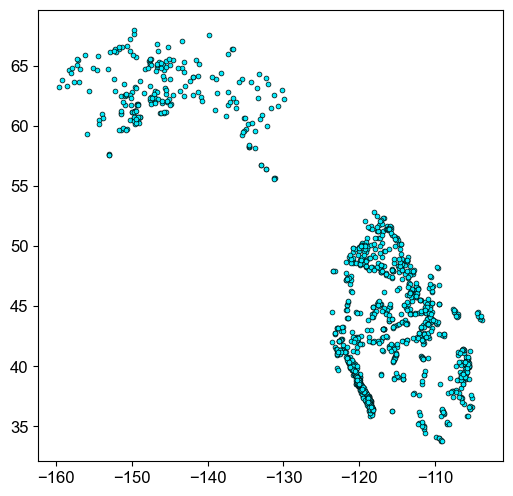

In [45]:
# Snow course locations
sc_file = "/Users/rdcrlrka/Research/GIS_data/NRCS_snow_course_stations.gpkg"
sc = gpd.read_file(sc_file)
sc = sc.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(6,6))
sc.plot(ax=ax, facecolor="#06ebfb", edgecolor='k', linewidth=0.5, marker='o', markersize=12)
ctx.add_basemap(ax=ax, crs=sc.crs, source=ctx.providers.Esri.WorldShadedRelief, attribution='', zoom=5)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig_file = os.path.join(OUT_DIR, "snow_course_locations.png")
fig.savefig(fig_file, dpi=250, bbox_inches='tight')
print("Figure saved to:", fig_file)

In [ ]:
# SNOTEL locations
sc_file = "/Users/rdcrlrka/Research/GIS_data/NRCS_stations_SNTL_ACTIVE_1474962434999921923.gpkg"
sc = gpd.read_file(sc_file)
sc = sc.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(6,6))
sc.plot(ax=ax, facecolor="#4EAD5B", edgecolor='k', linewidth=0.5, marker='o', markersize=12)
ctx.add_basemap(ax=ax, crs=sc.crs, source=ctx.providers.Esri.WorldShadedRelief, attribution='', zoom=5)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig_file = os.path.join(OUT_DIR, "SNOTEL_locations.png")
fig.savefig(fig_file, dpi=250, bbox_inches='tight')
print("Figure saved to:", fig_file)

In [ ]:
# EM spectrum and technologies diagram

fig, ax = plt.subplots(figsize=(20, 2), dpi=300)

# Wave with varying wavelengths
x = np.linspace(0.1, 10, 5000)
y = np.sin(2 * np.pi * (12 / (x + 0.5)))
ax.plot(x, y, color='k', linewidth=2, label='Electromagnetic Wave')

# tick labels
tick_positions = [1.0, 3.5, 6.0, 9.0]
tick_labels = [
    '10$^{-12}$ m\nGamma',
    '10$^{-6}$ m\nVisible',
    '10$^{-5}$ m\nInfrared',
    '10$^{-2}$ m\nMicrowave'
]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=11, fontweight='bold', color='#1e293b')

ax.set_yticks([])
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Set y-limits to make room for annotations at the bottom
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(0,)

plt.tight_layout()
plt.show()

fig_file = os.path.join(OUT_DIR, "EM_spectrum_plot.png")
fig.savefig(fig_file, dpi=300, transparent=True, bbox_inches='tight')
print("Figure saved to:", fig_file)

In [ ]:
# ---  Generate Simulated Data ---
np.random.seed(42)
# January 1: high uncertainty
mean_jan = 100  
std_dev_jan = 25
forecasts_jan = np.random.normal(mean_jan, std_dev_jan, 1000)
# April 1: Lower uncertainty
mean_apr = 130 
std_dev_apr = 8
forecasts_apr = np.random.normal(mean_apr, std_dev_apr, 1000)

# --- Create figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# --- Panel 1: January 1 Forecast
sns.histplot(forecasts_jan, kde=True, ax=ax1, color="#6baed6", bins=30, alpha=0.6, line_kws={'linewidth': 3})
ax1.set_title('January 1 Forecast (Early Season)', fontsize=14, fontweight='semibold', pad=15)
ax1.set_xlabel('Simulated April-July Runoff Volume (kAF)', fontsize=12, labelpad=10)
ax1.axvline(mean_jan, color='k', linestyle='--', linewidth=2, label=f'Mean Forecast: {mean_jan} kAF')


# --- Panel 2: April 1 Forecast
sns.histplot(forecasts_apr, kde=True, ax=ax2, color="#6baed6", bins=30, alpha=0.6, line_kws={'linewidth': 3})
ax2.set_title('April 1 Forecast (Late Season)', fontsize=14, fontweight='semibold', pad=15)
ax2.set_xlabel('Simulated April-July Runoff Volume (KAF)', fontsize=12, labelpad=10)
ax2.set_ylabel('')

ax2.axvline(mean_apr, color='k', linestyle='--', linewidth=2, label=f'Mean Forecast: {mean_apr} kAF')
common_xlim = [min(forecasts_jan.min(), forecasts_apr.min()) - 10,
               max(forecasts_jan.max(), forecasts_apr.max()) + 10]

for axis in [ax1, ax2]:
    axis.set_xlim(common_xlim)
    axis.set_ylim(0,110)
    axis.spines[['top', 'right']].set_visible(False)
    axis.set_ylabel('Frequency of Simulations (out of 1,000)', fontsize=12)


plt.tight_layout()

fig_file = os.path.join(OUT_DIR, "ESP_uncertainty comparison.png")
plt.savefig(fig_file, transparent=False, bbox_inches='tight')
print("Figure saved to:", fig_file)
plt.show()


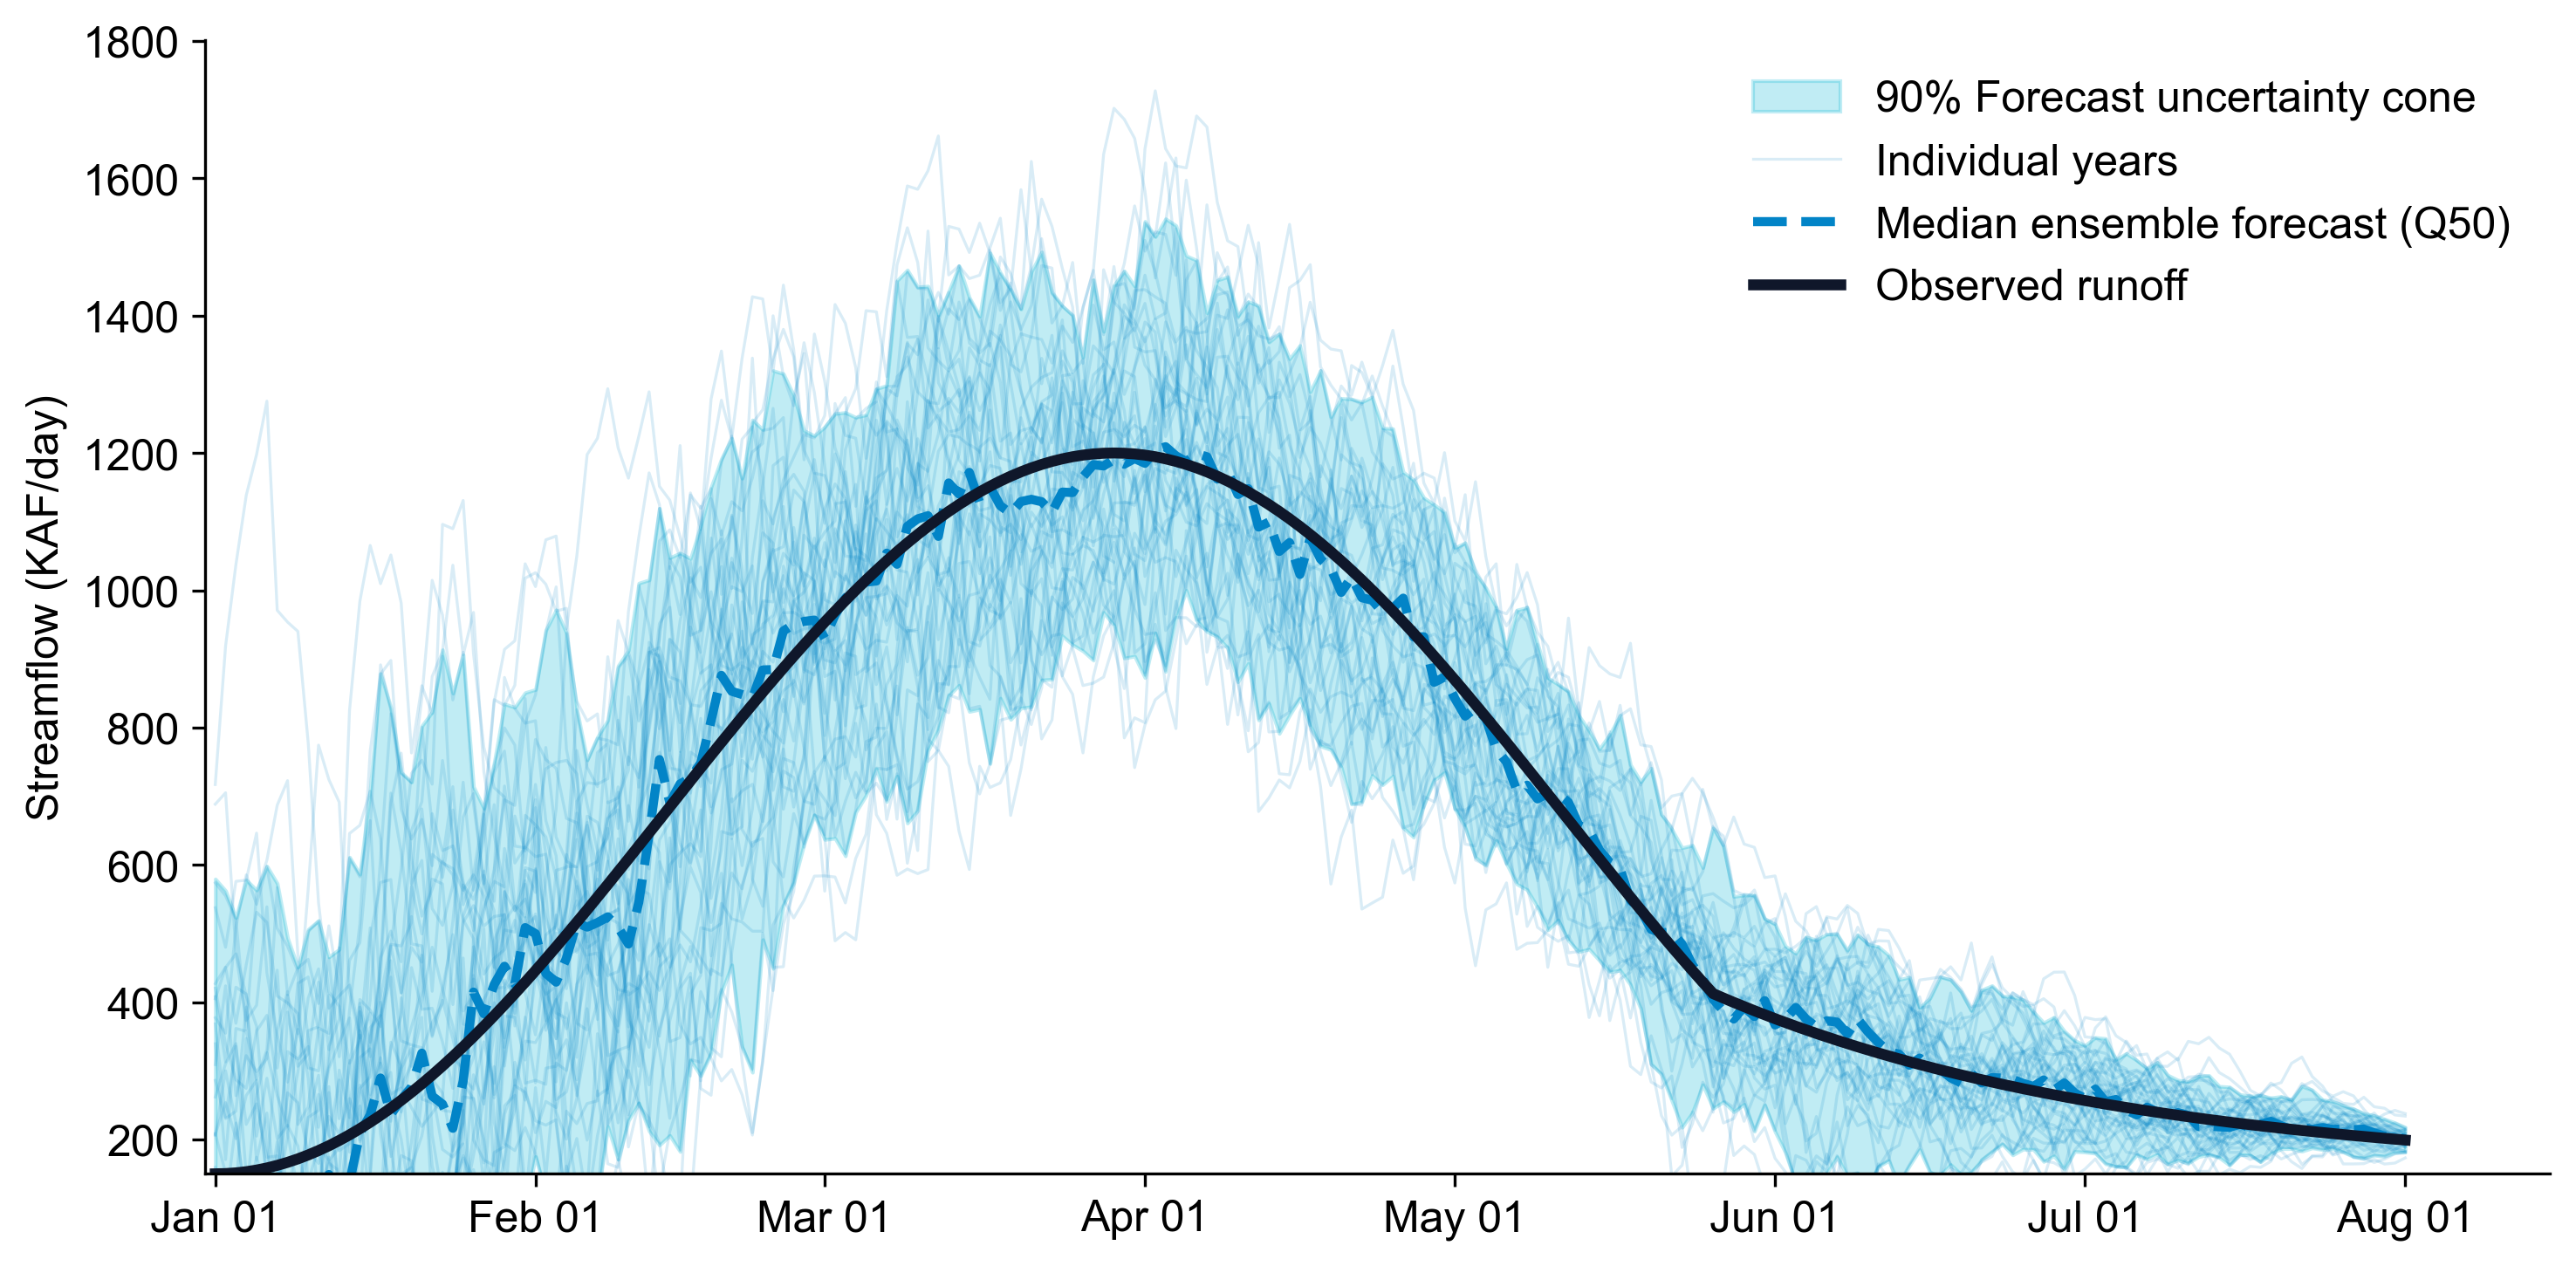

Figure saved to: /Users/rdcrlrka/Research/SIRO/SIRO_Workshop_2026_figures/ESP_cone_of_uncertainty.png


In [46]:
import pandas as pd

# Create a daily date range for a typical snowmelt season (Jan to Aug)
dates = pd.to_datetime(pd.date_range(start="2026-01-01", end="2026-08-01", freq="D"))
n_days = len(dates)

# Create the "Observed" Hydrograph
peak_day = 145  # Peak runoff day (late May)
peak_flow = 1200
baseflow = 150

# Rising melt pulse and exponential recession
observed_hydrograph = baseflow + (peak_flow - baseflow) * np.sin(np.pi * (np.arange(n_days) / (peak_day * 1.2)))**2
observed_hydrograph[peak_day:] = baseflow + (observed_hydrograph[peak_day] - baseflow) * np.exp(-0.025 * np.arange(n_days - peak_day))
observed_hydrograph = np.maximum(baseflow, observed_hydrograph)

# Create the Ensemble Forecast Traces
num_traces = 40
ensemble_forecasts = np.zeros((num_traces, n_days))

# Uncertainty (standard deviation) shrinks over time
max_uncertainty = 1000
uncertainty_decay = np.linspace(max_uncertainty, 40, n_days)

np.random.seed(42) 
for i in range(num_traces):
    # Generate random walking noise that respects the decaying uncertainty envelope
    noise = np.random.normal(0, uncertainty_decay)
    
    # Smooth the noise over a 10-day window to make the river traces look realistic/hydrological
    smoothed_noise = np.convolve(noise, np.ones(10)/10, mode='same')
    
    # Add smoothed noise to the base observed hydrograph
    ensemble_forecasts[i, :] = observed_hydrograph + smoothed_noise
    ensemble_forecasts[i, :] = np.maximum(baseflow - 50, ensemble_forecasts[i, :])  # Avoid negative/unrealistic flows

# Calculate percentiles for the "Cone"
p5 = np.percentile(ensemble_forecasts, 5, axis=0)
p95 = np.percentile(ensemble_forecasts, 95, axis=0)
median_forecast = np.percentile(ensemble_forecasts, 50, axis=0)


# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# 90% confidence interval
ax.fill_between(dates, p5, p95, color='#06b6d4', alpha=0.25, 
                label='90% Forecast uncertainty cone')

# Individual ensemble traces
# Plotting every trace with high transparency avoids a cluttered plot
for i in range(num_traces):
    ax.plot(dates, ensemble_forecasts[i, :], color='#0284c7', alpha=0.15, linewidth=0.8, 
            label='Individual years' if i == 0 else "")

# Median Ensemble Forecast
ax.plot(dates, median_forecast, color='#0284c7', linestyle='--', linewidth=2.5, 
        label='Median ensemble forecast (Q50)')

# D. Plot the "Observed" Hydrograph (The Ground Truth)
ax.plot(dates, observed_hydrograph, color='#0f172a', linewidth=3, 
        label='Observed runoff')

ax.set_ylabel('Streamflow (KAF/day)')

# Format X-axis with nice month abbreviations
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))

# # Add vertical lines representing key decision/forecast milestones
# forecast_dates = [
#     ("2026-01-01", "Jan 01 Forecast\nUncertainty: HIGH\n(Little snow accumulated yet)"),
#     ("2026-04-01", "Apr 01 Forecast\nUncertainty: LOWER\n(Peak snowpack known)")
# ]
# for date_str, label in forecast_dates:
#     d = pd.to_datetime(date_str)
#     ax.axvline(d, color='#ef4444', linestyle=':', linewidth=2)
#     ax.text(d, ax.get_ylim()[1] * 1.05, label, color='#b91c1c', 
#             ha='center', va='bottom', fontweight='bold',
#             bbox=dict(facecolor='#fef2f2', edgecolor='#fca5a5', boxstyle='round,pad=0.4'))

ax.legend(loc='upper right', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(pd.to_datetime("2025-12-31"), pd.to_datetime("2026-08-15"))
ax.set_ylim(baseflow,1801)
plt.tight_layout()

plt.show()

fig_file = os.path.join(OUT_DIR, "ESP_cone_of_uncertainty.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight', transparent=False)
print("Figure saved to:", fig_file)


Figure saved to: /Users/rdcrlrka/Research/SIRO/SIRO_Workshop_2026_figures/SNOTEL_USGS_stream_gauge_locator_map.png


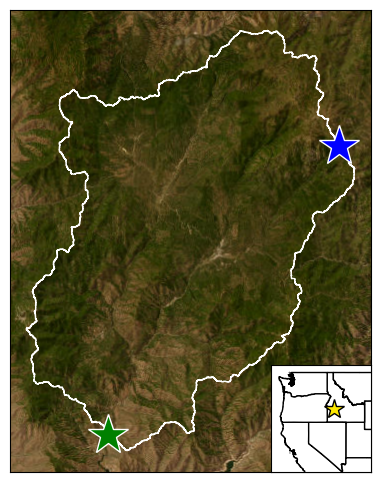

In [30]:
# --- MCS SNOTEL and USGS stream gauge locations ---

from shapely.geometry import Point

states_file = "/Users/rdcrlrka/Research/GIS_data/cb_2024_us_all_500k/cb_2024_us_state_500k/cb_2024_us_state_500k.shp"
states = gpd.read_file(states_file)

basin_outline_file = "/Users/rdcrlrka/Research/SIRO/MCS_outline.gpkg"
basin_outline = gpd.read_file(basin_outline_file)

snotel_coords = [-115.66587829589844, 43.93199920654297]
usgs_coords = [-115.9897222, 43.64805556]


fig, ax1 = plt.subplots(figsize=(5,6))

# Closer look
basin_outline.plot(ax=ax1, facecolor='None', edgecolor='w')

for coords, color, label in [
    [snotel_coords, 'b', 'SNOTEL'], 
    [usgs_coords, 'g', 'USGS Stream Gauge']
    ]:
    gdf = gpd.GeoDataFrame(geometry=[Point(coords)], crs="EPSG:4326").to_crs("EPSG:32611")
    ax1.plot(
        *gdf.geometry[0].coords.xy, '*', markersize=30, markerfacecolor=color, markeredgecolor='w', linewidth=0.5
        )

ctx.add_basemap(
    ax=ax1, crs="EPSG:32611", source=ctx.providers.Esri.WorldImagery, zoom=10,
    attribution=""
    )
ax1.set_xticks([])
ax1.set_yticks([])

# Locator map
# create small inset axes that align on the right and bottom 
w,h = 0.2, 0.2
x0 = ax1.get_position().x0 + ax1.get_position().width - w
y0 = ax1.get_position().y0 - 0.012
ax0 = fig.add_axes([x0, y0, w, h])
states.plot(ax=ax0, facecolor='w', edgecolor='k')
basin_outline_wgs = basin_outline.to_crs("EPSG:4326")
ax0.plot(
    *basin_outline_wgs.geometry[0].centroid.coords.xy, '*', markerfacecolor="#fde800", markeredgecolor='k', linewidth=0.5, markersize=15
    )
ax0.set_xlim(-126, -110)
ax0.set_ylim(35, 50)
ax0.set_xticks([])
ax0.set_yticks([])

fig_file = os.path.join(OUT_DIR, "SNOTEL_USGS_stream_gauge_locator_map.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)
plt.show()

/var/folders/46/lc6lgy656cq4n776s7js9r880000gr/T/ipykernel_76049/2467290181.py:27: RuntimeWarning: invalid value encountered in sqrt
  forecast_hydrograph[obs_dayf:] = forecast_hydrograph[obs_dayf] + (peak_flow - forecast_hydrograph[obs_dayf]) * np.sin(np.pi * ((np.arange(n_days - obs_dayf)) / (peak_day * 1.2)))**0.5


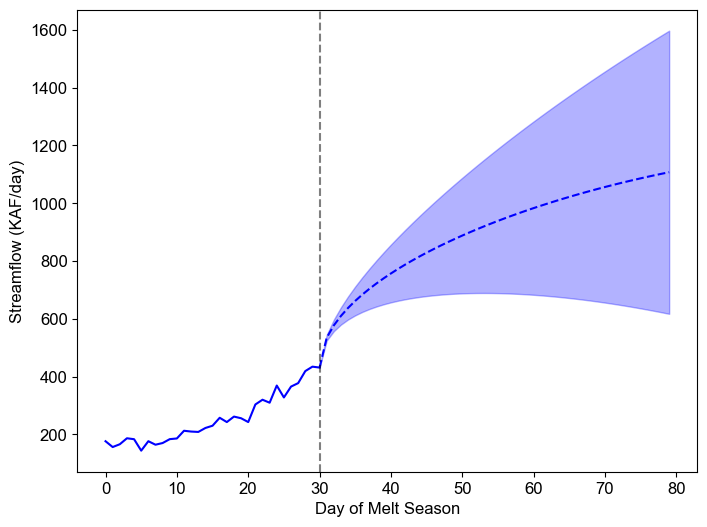

Figure saved to: /Users/rdcrlrka/Research/SIRO/SIRO_Workshop_2026_figures/melt_projections_CM_varying.png


In [57]:
# Base curve
peak_day = 145  # Peak runoff day (late May)
peak_flow = 1200
baseflow = 150
dates = pd.to_datetime(pd.date_range(start="2026-01-01", end="2026-08-01", freq="D"))
n_days = len(dates)
observed_hydrograph = baseflow + (peak_flow - baseflow) * np.sin(np.pi * (np.arange(n_days) / (peak_day * 1.2)))**2
observed_hydrograph[peak_day:] = baseflow + (observed_hydrograph[peak_day] - baseflow) * np.exp(-0.025 * np.arange(n_days - peak_day))
observed_hydrograph = np.maximum(baseflow, observed_hydrograph)

obs_dayf = 30
proj_dayf = 80

# Add noise to the observed portion
# Set a seed for reproducibility
np.random.seed(0)
# Define noise characteristics
noise_level = 15  # Standard deviation of the noise
# Generate and add noise to the observed part of the hydrograph
noise = np.random.normal(0, noise_level, obs_dayf + 1)
observed_hydrograph[0:obs_dayf+1] += noise

# Create windows that diverge from the observed hydrograph at obs_dayf
# The starting point for the window is now the last noisy observation
forecast_hydrograph = observed_hydrograph.copy()
# Recalculate the forecast part based on a smooth curve starting from the last obs point
forecast_hydrograph[obs_dayf:] = forecast_hydrograph[obs_dayf] + (peak_flow - forecast_hydrograph[obs_dayf]) * np.sin(np.pi * ((np.arange(n_days - obs_dayf)) / (peak_day * 1.2)))**0.5
forecast_hydrograph[peak_day:] = baseflow + (forecast_hydrograph[peak_day] - baseflow) * np.exp(-0.025 * np.arange(n_days - peak_day))

time_since_obs = np.arange(n_days) - obs_dayf
divergence = np.zeros(n_days)
# Make the divergence start at 0 and grow
divergence[obs_dayf:proj_dayf] = 500 * (time_since_obs[obs_dayf:proj_dayf] / (proj_dayf - obs_dayf))

# The windows are centered around the forecast, not the original smooth curve
min_window = forecast_hydrograph - divergence
max_window = forecast_hydrograph + divergence

fig, ax = plt.subplots(figsize=(8, 6))
# Plot the noisy observed data
ax.plot(np.arange(0, len(observed_hydrograph))[0:obs_dayf+1], observed_hydrograph[0:obs_dayf+1], '-b')
# Plot the forecast data
ax.plot(np.arange(0, len(observed_hydrograph))[obs_dayf:proj_dayf], forecast_hydrograph[obs_dayf:proj_dayf], '--b')
ax.fill_between(
    np.arange(0, len(observed_hydrograph))[obs_dayf:proj_dayf],
    min_window[obs_dayf:proj_dayf],
    max_window[obs_dayf:proj_dayf],
    color='b',
    alpha=0.3
)
ax.axvline(obs_dayf, linestyle='--', color='k', alpha=0.5)
ax.set_ylabel("Streamflow (KAF/day)")
ax.set_xlabel("Day of Melt Season")

plt.show()


fig_file = os.path.join(OUT_DIR, "melt_projections_CM_varying.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight')
print("Figure saved to:", fig_file)


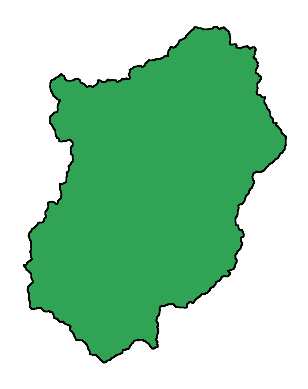

Figure saved to: /Users/rdcrlrka/Research/SIRO/SIRO_Workshop_2026_figures/Mores_basin_outline.png


In [62]:
# Simple basin outline plot
fig, ax = plt.subplots()
basin_outline.plot(ax=ax, edgecolor='k', facecolor='#31a354')
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

plt.show()

fig_file = os.path.join(OUT_DIR, "Mores_basin_outline.png")
fig.savefig(fig_file, dpi=300, bbox_inches='tight', transparent=True)
print("Figure saved to:", fig_file)
